# PlantUML no IJava — demo

Este notebook demonstra a mágica de célula `%%plantuml`: diagramas escritos como texto viram imagens `image/png` geradas **localmente** (offline), que o Callisto renderiza nativamente no blog e no livro.

In [2]:
%maven net.sourceforge.plantuml:plantuml:1.2024.3

In [3]:
import io.github.spencerpark.ijava.runtime.Kernel;
import io.github.spencerpark.ijava.runtime.Display;
import net.sourceforge.plantuml.SourceStringReader;
import java.awt.image.BufferedImage;
import java.io.ByteArrayOutputStream;
import javax.imageio.ImageIO;

Kernel.getKernelInstance().getMagics().registerCellMagic("plantuml", (args, body) -> {
    String uml = body.strip();
    if (!uml.startsWith("@startuml")) {
        uml = "@startuml\n" + uml + "\n@enduml";
    }
    try {
        SourceStringReader reader = new SourceStringReader(uml);
        ByteArrayOutputStream os = new ByteArrayOutputStream();
        reader.outputImage(os);
        os.close();
        BufferedImage img = ImageIO.read(new java.io.ByteArrayInputStream(os.toByteArray()));
        Display.display(img); // publica display_data image/png (%% descarta return)
        return null;
    } catch (Exception e) {
        return "Erro PlantUML: " + e.getMessage();
    }
});

## Diagrama de sequência (sem tags — a mágica completa)

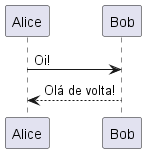

In [4]:
%%plantuml
Alice -> Bob: Oi!
Bob --> Alice: Olá de volta!

## Diagrama com tags `@startuml` (usado como está)

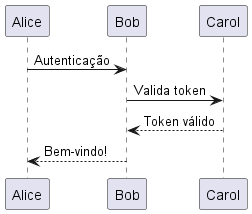

In [5]:
%%plantuml
@startuml
Alice -> Bob: Autenticação
Bob -> Carol: Valida token
Carol --> Bob: Token válido
Bob --> Alice: Bem-vindo!
@enduml